In [40]:
# 

# ==============================================================================
# STEP 1: SETUP & OPTIMIZATION
# ==============================================================================
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# ปรับการแสดงผลเพื่อให้ Tracking ข้อมูลได้ง่าย
pd.set_option('display.max_columns', None)
sns.set_theme(style="whitegrid")



In [41]:
# ==============================================================================
# STEP 2: DATA LOADING (Handling Categorical Labels)
# ==============================================================================
# Why: ใช้ convert_categoricals=False เพื่อป้องกัน Error จากชื่อซ้ำใน Metadata ของ Stata
file_2016 = 'wave-6-shocksclean.dta'
df_16 = pd.read_stata(file_2016, convert_categoricals=False)

print(f"Loaded Wave 6 (2016) successfully: {len(df_16)} rows")



Loaded Wave 6 (2016) successfully: 3323 rows


In [42]:
# ==============================================================================
# STEP 3: ADVANCED DATA CLEANING
# ==============================================================================
# จัดการค่าว่างและ 'none' เพื่อป้องกัน ValueError
def research_cleaning(df):
    # เปลี่ยนรหัส Missing Stata
    df = df.replace([-9, -99, -9.0, -99.0], np.nan)
    
    # จัดการคอลัมน์การเงิน (Total Loss: _x31005a)
    target_cols = ['_x31005a', '_x31005b', '_x31006a']
    for col in target_cols:
        if col in df.columns:
            df[col] = df[col].astype(str).str.replace('none', '0', case=False).str.strip()
            df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0)
    return df

df_16 = research_cleaning(df_16)



In [43]:
# ==============================================================================
# STEP 4: COPING STRATEGY RECONSTRUCTION (เจาะลึก _x31008)
# ==============================================================================
# Why: แปลงจากคำตอบแบบลำดับ (1st, 2nd, 3rd) ให้เป็น Binary (Yes/No) เหมือนปี 2022
coping_mapping = {
    11: 'sold_assets', 12: 'sold_assets', 13: 'sold_assets', 14: 'sold_assets',
    15: 'used_savings', 16: 'used_insurance',
    17: 'borrowed_informal', 18: 'borrowed_informal', 19: 'borrowed_informal', 20: 'borrowed_informal',
    21: 'borrowed_formal', 22: 'borrowed_formal', 23: 'borrowed_formal', 24: 'borrowed_formal', 25: 'borrowed_formal',
    28: 'gov_help', 29: 'gov_help', 30: 'relatives_help', 31: 'relatives_help'
}

# สร้างคอลัมน์ Yes/No (0 หรือ 1)
coping_categories = ['sold_assets', 'used_savings', 'used_insurance', 'borrowed_informal', 'borrowed_formal', 'gov_help']
for cat in coping_categories:
    df_16[f'coping_{cat}'] = 0

# ตรวจสอบการใช้งานจากทุกลำดับ (Coping 1, 2, 3)
for col in ['_x31008', '_x31009', '_x31010']:
    if col in df_16.columns:
        for code, cat_name in coping_mapping.items():
            df_16.loc[df_16[col] == code, f'coping_{cat_name}'] = 1



C:\Users\kitti\AppData\Local\Temp\ipykernel_18112\1162508011.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_16, x='shocks_Group', palette='Set2')


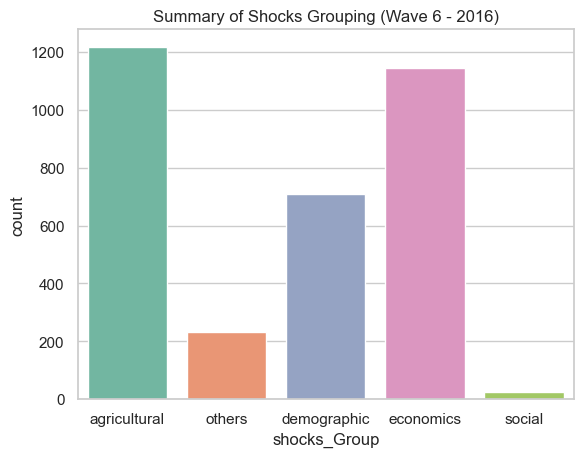

✅ Process Completed. File saved as shocks_2016_cleaned_final.csv


In [44]:
# ==============================================================================
# STEP 5: SHOCK CATEGORIZATION (Harmonization)
# ==============================================================================
# Mapping รหัส Shock (_x31002) เข้ากลุ่มมาตรฐาน
shock_mapping = {
    10: 'agricultural', 11: 'agricultural', 63: 'agricultural', 55: 'agricultural',
    1: 'demographic', 2: 'demographic', 3: 'demographic', 24: 'demographic',
    5: 'economics', 6: 'economics', 18: 'economics', 21: 'economics', 22: 'economics', 62: 'economics',
    8: 'social', 70: 'social', 77: 'economics'
}

# สร้างตัวแปรวิเคราะห์
df_16['shocks_Group'] = df_16['_x31002'].map(shock_mapping).fillna('others')
df_16['survey_year'] = 2016

# ==============================================================================
# STEP 6: EXPORT & FINAL SUMMARY
# ==============================================================================
output_file = 'shocks_2016_cleaned_final.csv'
df_16.to_csv(output_file, index=False)

# แสดงกราฟสรุปเพื่อ Recheck ข้อมูล
sns.countplot(data=df_16, x='shocks_Group', palette='Set2')
plt.title('Summary of Shocks Grouping (Wave 6 - 2016)')
plt.show()

print(f"✅ Process Completed. File saved as {output_file}")

--- Starting Analysis and Saving Graphs for Year 2016 ---


C:\Users\kitti\AppData\Local\Temp\ipykernel_18112\2598171748.py:48: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='shocks_Group', palette='viridis', order=df['shocks_Group'].value_counts().index)


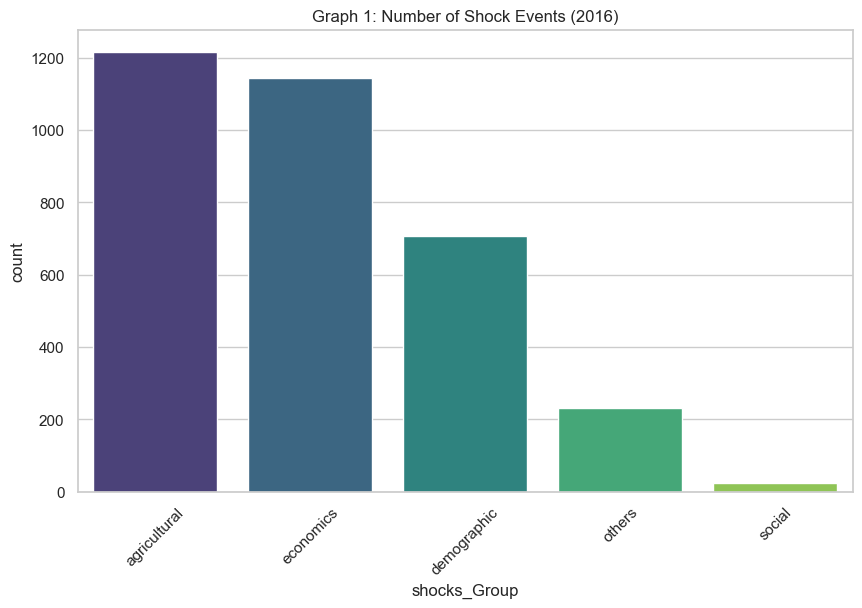

C:\Users\kitti\AppData\Local\Temp\ipykernel_18112\2598171748.py:58: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='shocks_Group', y='impact_3way', estimator=np.mean, palette='magma')


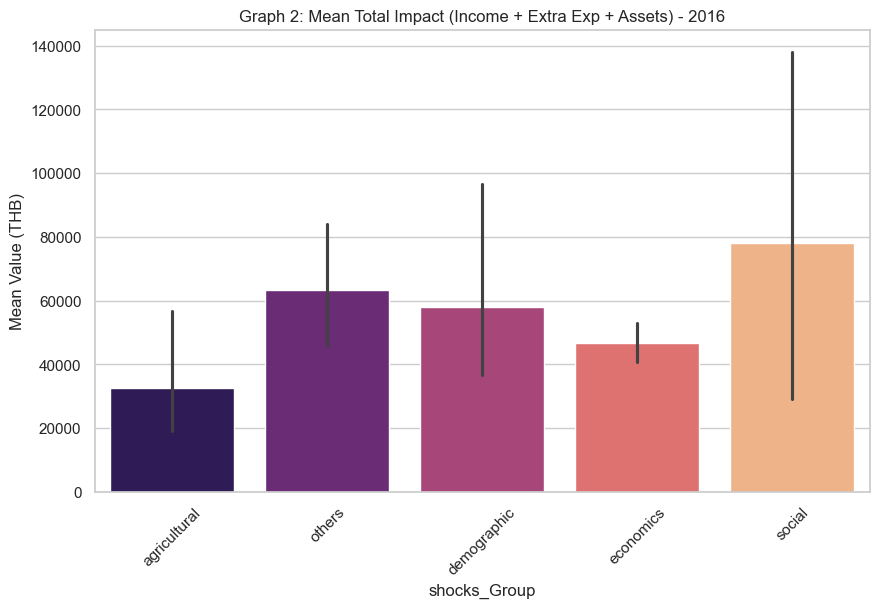

C:\Users\kitti\AppData\Local\Temp\ipykernel_18112\2598171748.py:69: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='shocks_Group', y='impact_2way', estimator=np.mean, palette='flare')


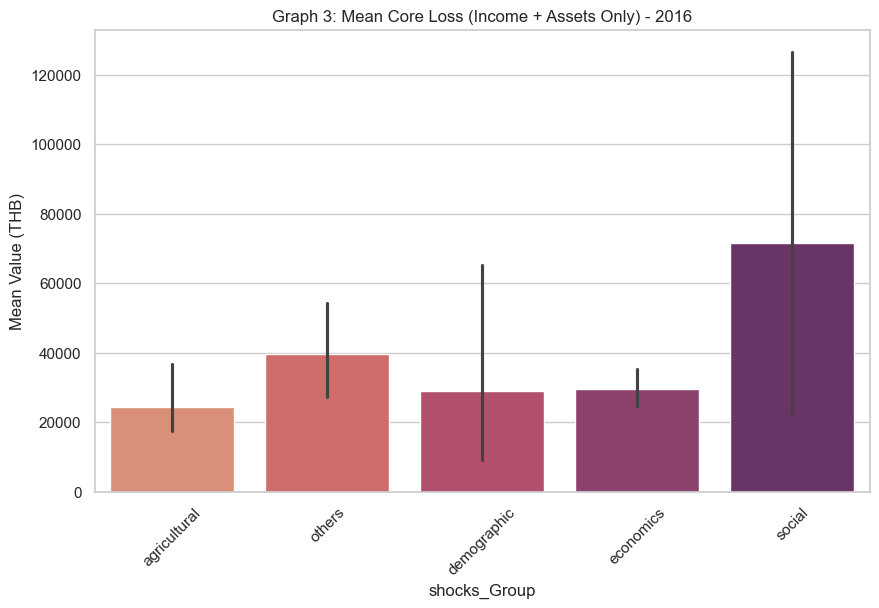

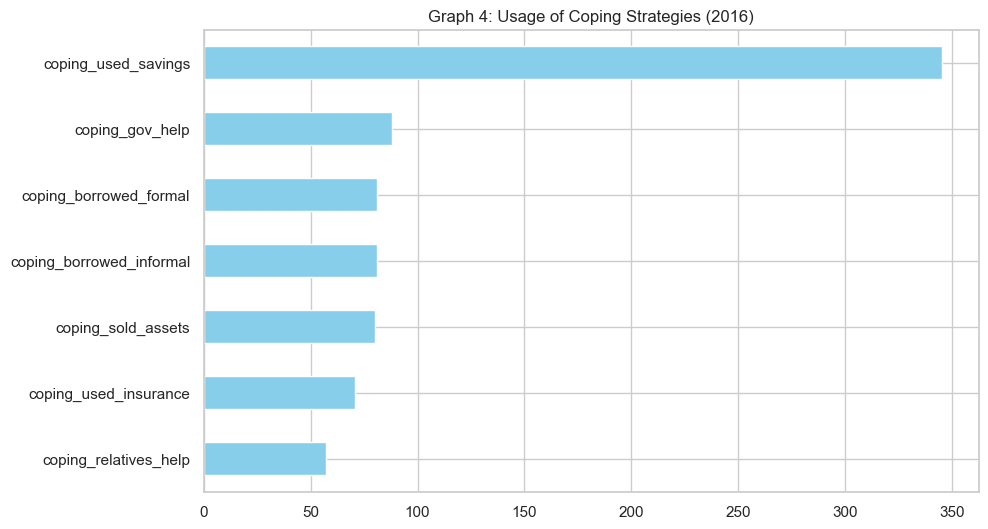

C:\Users\kitti\AppData\Local\Temp\ipykernel_18112\2598171748.py:92: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='coping_count', palette='plasma')


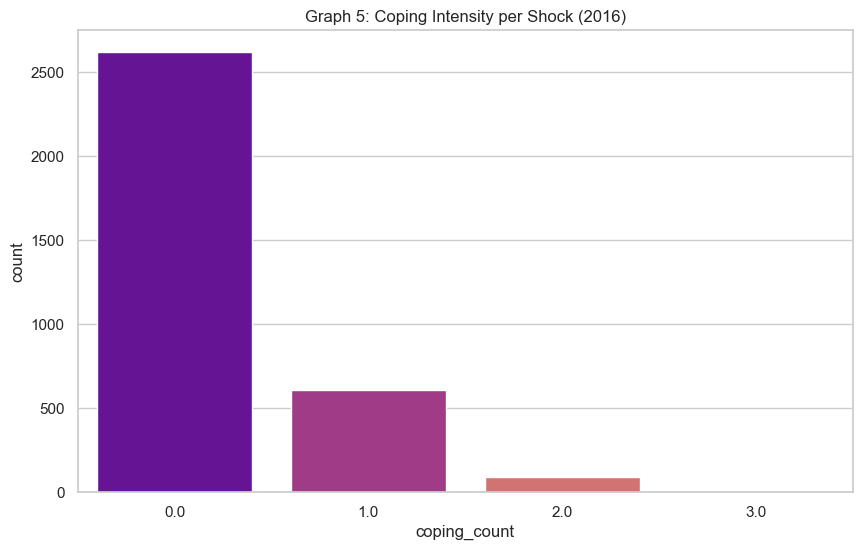

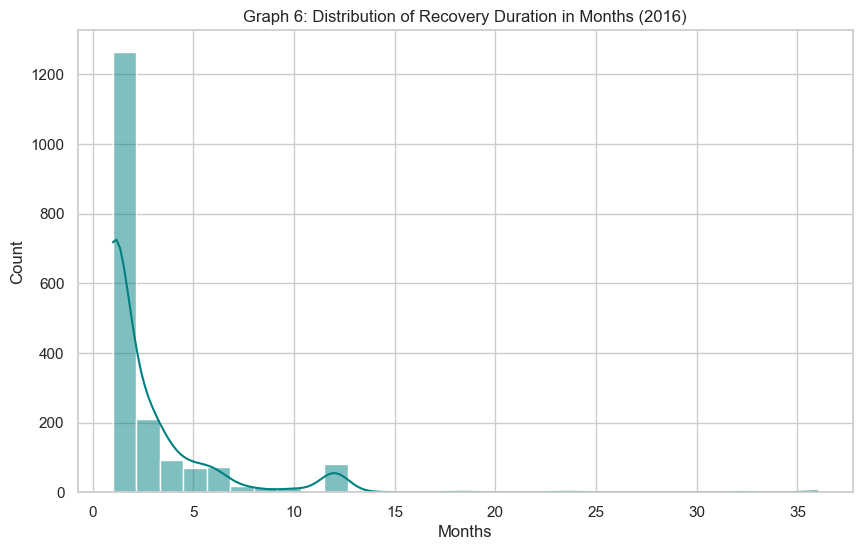

C:\Users\kitti\AppData\Local\Temp\ipykernel_18112\2598171748.py:112: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='recovery_standardized', order=recovery_order, palette='Set2')


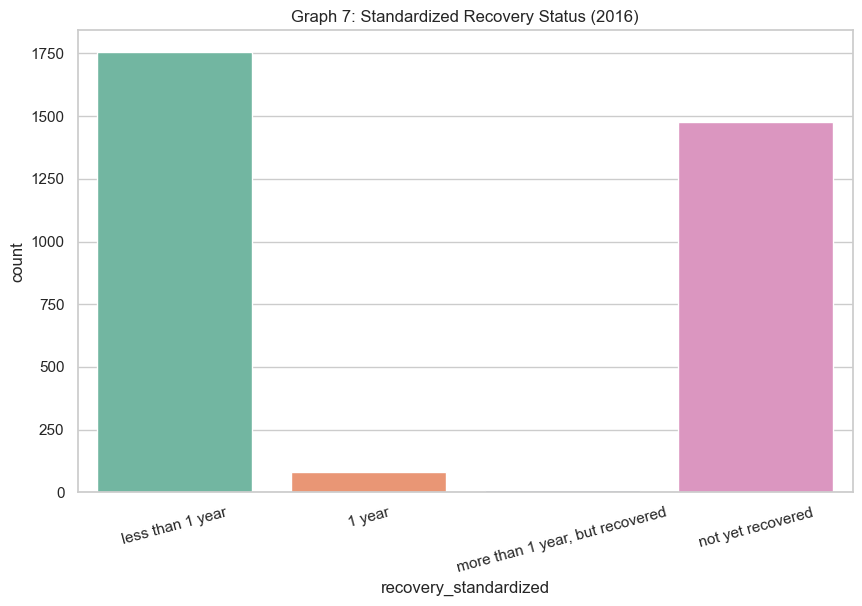

C:\Users\kitti\AppData\Local\Temp\ipykernel_18112\2598171748.py:122: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df[df['consumption_label'].notnull()], x='consumption_label', palette='Set1')


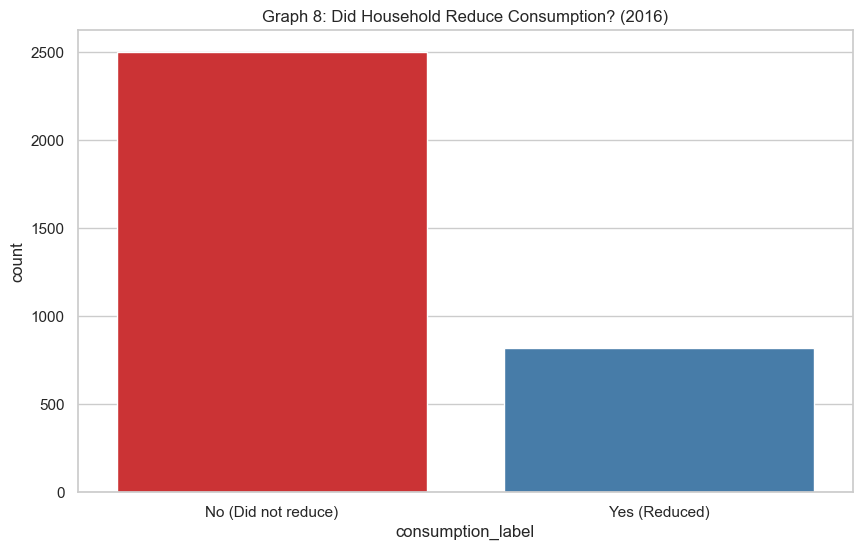

--- All graphs saved in folder: Descriptive_Graph_2016 ---


In [45]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import os

def run_and_save_all_graphs(df, year):
    # สร้างโฟลเดอร์สำหรับเก็บรูปถ้ายังไม่มี
    output_dir = f"Descriptive_Graph_{year}"
    if not os.path.exists(output_dir):
        os.makedirs(output_dir)
        
    # --- PRE-PROCESSING ---
    # 1. จัดการข้อมูลเงิน (ตรวจสอบชื่อคอลัมน์ให้ตรงตามแต่ละ Wave)
    # สำหรับ Wave 6: _x31005a, _x31005b, _x31006a
    loss_cols = ['_x31005a', '_x31005b', '_x31006a']
    for col in loss_cols:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col].astype(str).str.replace('none', '0'), errors='coerce').fillna(0)
    
    # คำนวณตามโจทย์ (กราฟ 2 และ 3)
    df['impact_3way'] = df['_x31005a'] + df['_x31005b'] + df['_x31006a']
    df['impact_2way'] = df['_x31005a'] + df['_x31006a']

    # 2. จัดการ Recovery Standardized (เข้ากับ Wave 1)
    # สำหรับ Wave 6 ใช้ _x31012a (หน่วยเดือน)
    def map_to_wave1_recovery(m):
        if m < 12: return "less than 1 year"
        if m == 12: return "1 year"
        if 12 < m < 90: return "more than 1 year, but recovered"
        if m == 90: return "not yet recovered"
        return np.nan
    df['recovery_standardized'] = df['_x31012a'].apply(map_to_wave1_recovery)
    
    # 3. จัดการ Consumption Label (_x31011)
    consumption_map = {1: "Yes (Reduced)", 2: "No (Did not reduce)"}
    df['consumption_label'] = df['_x31011'].map(consumption_map)

    print(f"--- Starting Analysis and Saving Graphs for Year {year} ---")

    # ตั้งค่า Font และสไตล์พื้นฐาน
    sns.set_theme(style="whitegrid")

    # ---------------------------------------------------------
    # Graph 1: Frequency
    # ---------------------------------------------------------
    plt.figure(figsize=(10, 6))
    sns.countplot(data=df, x='shocks_Group', palette='viridis', order=df['shocks_Group'].value_counts().index)
    plt.title(f'Graph 1: Number of Shock Events ({year})')
    plt.xticks(rotation=45)
    plt.savefig(f'{output_dir}/G1_Frequency_{year}.png', dpi=300, bbox_inches='tight')
    plt.show()

    # ---------------------------------------------------------
    # Graph 2: Mean Total Impact (3-way)
    # ---------------------------------------------------------
    plt.figure(figsize=(10, 6))
    sns.barplot(data=df, x='shocks_Group', y='impact_3way', estimator=np.mean, palette='magma')
    plt.title(f'Graph 2: Mean Total Impact (Income + Extra Exp + Assets) - {year}')
    plt.ylabel('Mean Value (THB)')
    plt.xticks(rotation=45)
    plt.savefig(f'{output_dir}/G2_MeanImpact_3way_{year}.png', dpi=300, bbox_inches='tight')
    plt.show()

    # ---------------------------------------------------------
    # Graph 3: Mean Core Loss (2-way)
    # ---------------------------------------------------------
    plt.figure(figsize=(10, 6))
    sns.barplot(data=df, x='shocks_Group', y='impact_2way', estimator=np.mean, palette='flare')
    plt.title(f'Graph 3: Mean Core Loss (Income + Assets Only) - {year}')
    plt.ylabel('Mean Value (THB)')
    plt.xticks(rotation=45)
    plt.savefig(f'{output_dir}/G3_MeanLoss_2way_{year}.png', dpi=300, bbox_inches='tight')
    plt.show()

    # ---------------------------------------------------------
    # Graph 4: Coping Usage
    # ---------------------------------------------------------
    plt.figure(figsize=(10, 6))
    coping_vars = [c for c in df.columns if c.startswith('coping_')]
    if coping_vars:
        df[coping_vars].sum().sort_values().plot(kind='barh', color='skyblue')
        plt.title(f'Graph 4: Usage of Coping Strategies ({year})')
        plt.savefig(f'{output_dir}/G4_CopingUsage_{year}.png', dpi=300, bbox_inches='tight')
    plt.show()

    # ---------------------------------------------------------
    # Graph 5: Coping Intensity
    # ---------------------------------------------------------
    plt.figure(figsize=(10, 6))
    df['coping_count'] = df[coping_vars].sum(axis=1)
    sns.countplot(data=df, x='coping_count', palette='plasma')
    plt.title(f'Graph 5: Coping Intensity per Shock ({year})')
    plt.savefig(f'{output_dir}/G5_CopingIntensity_{year}.png', dpi=300, bbox_inches='tight')
    plt.show()

    # ---------------------------------------------------------
    # Graph 6: Recovery Duration (Months)
    # ---------------------------------------------------------
    plt.figure(figsize=(10, 6))
    sns.histplot(data=df[df['_x31012a'] < 90], x='_x31012a', bins=30, kde=True, color='teal')
    plt.title(f'Graph 6: Distribution of Recovery Duration in Months ({year})')
    plt.xlabel('Months')
    plt.savefig(f'{output_dir}/G6_RecoveryMonths_{year}.png', dpi=300, bbox_inches='tight')
    plt.show()

    # ---------------------------------------------------------
    # Graph 7: Standardized Recovery
    # ---------------------------------------------------------
    plt.figure(figsize=(10, 6))
    recovery_order = ["less than 1 year", "1 year", "more than 1 year, but recovered", "not yet recovered"]
    sns.countplot(data=df, x='recovery_standardized', order=recovery_order, palette='Set2')
    plt.title(f'Graph 7: Standardized Recovery Status ({year})')
    plt.xticks(rotation=15)
    plt.savefig(f'{output_dir}/G7_RecoveryStandardized_{year}.png', dpi=300, bbox_inches='tight')
    plt.show()

    # ---------------------------------------------------------
    # Graph 8: Consumption Reduction
    # ---------------------------------------------------------
    plt.figure(figsize=(10, 6))
    sns.countplot(data=df[df['consumption_label'].notnull()], x='consumption_label', palette='Set1')
    plt.title(f'Graph 8: Did Household Reduce Consumption? ({year})')
    plt.savefig(f'{output_dir}/G8_ConsumptionReduction_{year}.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print(f"--- All graphs saved in folder: {output_dir} ---")

# เรียกใช้งาน
run_and_save_all_graphs(df_16, 2016)